<a href="https://colab.research.google.com/github/yousuf1028313/customer-churn-prediction/blob/main/telco_customer_churn_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
df = pd.read_csv(r'/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
print(df.columns.tolist())
print(df['Churn'].value_counts())

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Import & Load Data

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Clean the data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Keep only numeric columns for now
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
X = df[features]
y = df['Churn']

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)

print('Accuracy:', model.score(X_test, y_test))

Accuracy: 0.7583511016346838


## Basic Info

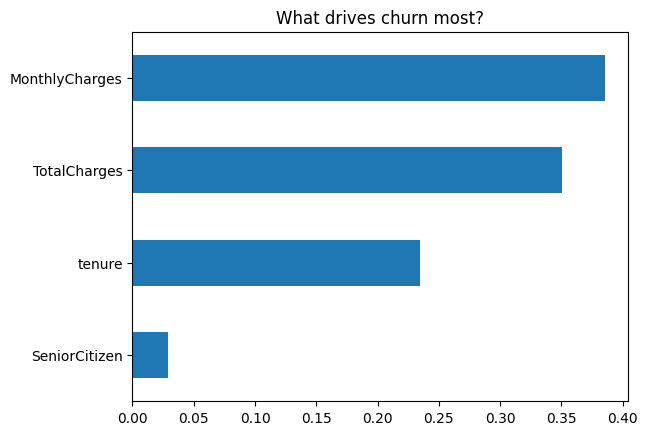

In [11]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', title='What drives churn most?')
plt.show()

In [12]:
print("High risk customers:")
print(df[df['Churn']==1]['MonthlyCharges'].describe())
print("\nLow risk customers:")
print(df[df['Churn']==0]['MonthlyCharges'].describe())

High risk customers:
count    1869.000000
mean       74.441332
std        24.666053
min        18.850000
25%        56.150000
50%        79.650000
75%        94.200000
max       118.350000
Name: MonthlyCharges, dtype: float64

Low risk customers:
count    5163.000000
mean       61.307408
std        31.094557
min        18.250000
25%        25.100000
50%        64.450000
75%        88.475000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Checking for Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

## Checking for Missing Values

In [ ]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## groupby

In [ ]:
df.groupby("customerID")["gender"].sum().reset_index()

,customerID,gender
0,0002-ORFBO,Female
1,0003-MKNFE,Male
2,0004-TLHLJ,Male
3,0011-IGKFF,Male
4,0013-EXCHZ,Female
...,...,...
7038,9987-LUTYD,Female
7039,9992-RRAMN,Male
7040,9992-UJOEL,Male
7041,9993-LHIEB,Male


## Feature Distributions

<Figure size 1200x800 with 0 Axes>

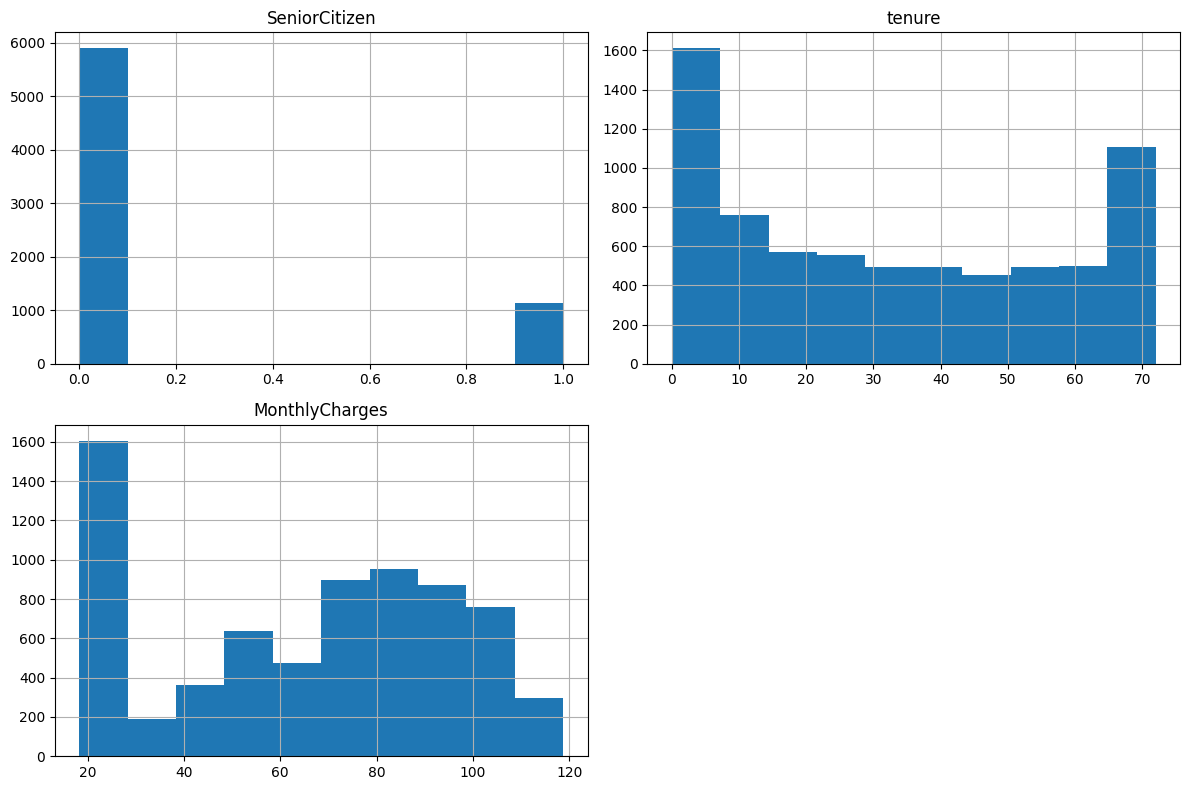

In [ ]:
plt.figure(figsize=(12, 8))
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Boxplots (Outlier Detection)

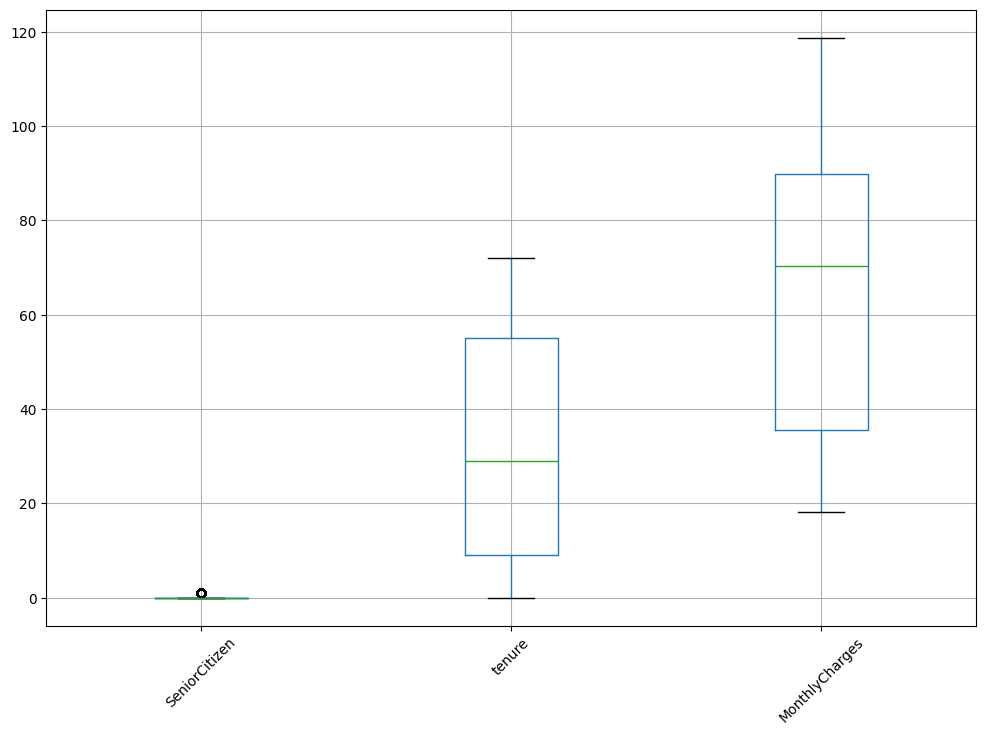

In [ ]:
plt.figure(figsize=(12, 8))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Heatmap

In [ ]:

numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
corr_long = corr_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Feature1', 'Feature2', 'Correlation']
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1,
    zmax=1,
    aspect='auto',
    title='Correlation Heatmap of Numeric Features (Telco Customer Churn)'
)

fig.show()


## MRP

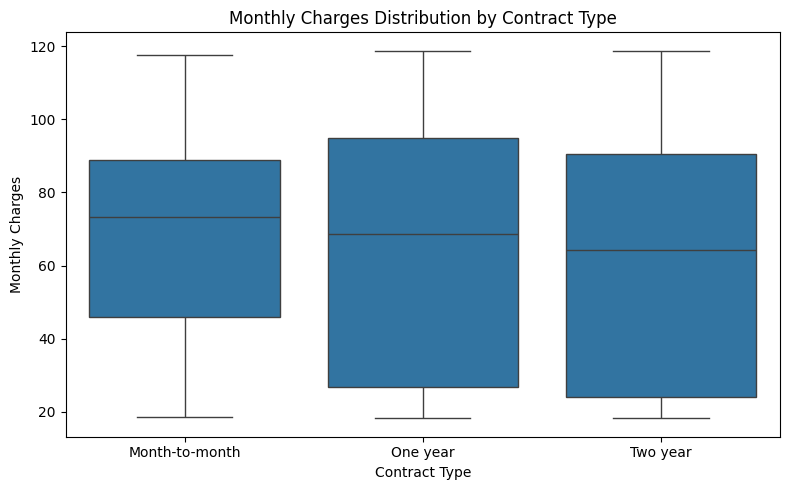

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges')
plt.title('Monthly Charges Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()


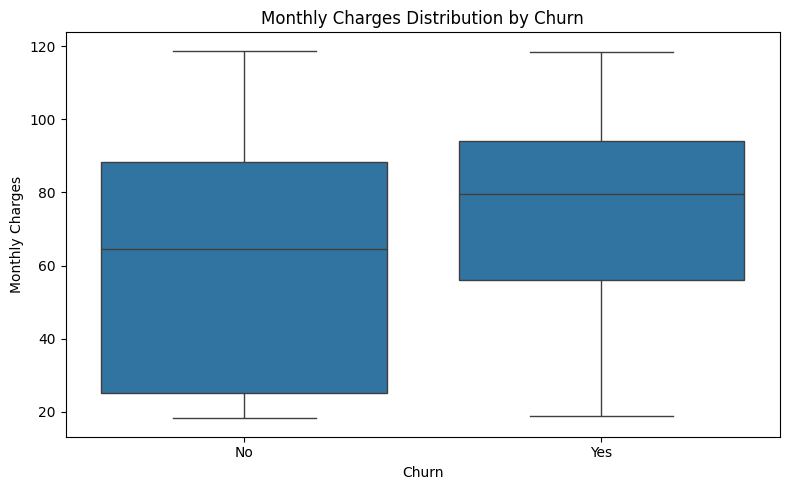

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.tight_layout()
plt.show()


## barchart

In [ ]:
import plotly.express as px

top_payment_methods = (
    df['PaymentMethod']
    .value_counts()
    .nlargest(20)
    .reset_index()
)

top_payment_methods.columns = ['PaymentMethod', 'Count']

fig = px.bar(
    top_payment_methods,
    x='Count',
    y='PaymentMethod',
    orientation='h',
    title='Top Payment Methods in Telco Customer Churn Dataset'
)

fig.update_layout(
    height=600,
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()


## scatter

In [ ]:
import plotly.express as px
import pandas as pd

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig = px.scatter(
    df,
    x='MonthlyCharges',
    y='TotalCharges',
    color='Churn',
    hover_data=[
        'Contract',
        'InternetService',
        'PaymentMethod',
        'tenure'
    ],
    title='Monthly Charges vs Total Charges by Churn'
)

fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig = px.scatter(
    df,
    x='MonthlyCharges',
    y='TotalCharges',
    color='Churn',
    facet_col='Contract',
    hover_data=[
        'tenure',
        'InternetService',
        'PaymentMethod'
    ],
    title='Monthly Charges vs Total Charges by Churn and Contract Type'
)

fig.update_layout(
    height=500
)

fig.show()


## Bubble Scatter: Monthly vs Total Charges

In [ ]:
fig = px.scatter(
    df,
    x='MonthlyCharges',
    y='TotalCharges',
    size='tenure',
    color='Contract',
    hover_data=[
        'Churn',
        'InternetService',
        'PaymentMethod'
    ],
    title='Monthly Charges vs Total Charges by Contract Type',
    size_max=60
)

fig.show()


## Bubble Scatter: Total Charges vs Tenure

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig = px.scatter(
    df,
    x='TotalCharges',
    y='tenure',
    size='MonthlyCharges',
    color='Churn',
    hover_data=[
        'Contract',
        'InternetService',
        'PaymentMethod',
        'SeniorCitizen',
        'gender'
    ],
    title='Total Charges vs Tenure with Monthly Charges Bubble Size',
    size_max=60
)

fig.show()

## treemap

In [ ]:


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig = px.treemap(
    df,
    path=['Contract'],
    values='TotalCharges',
    title='Treemap of Total Charges by Contract Type'
)

fig.show()


In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['Churn'] = df['Churn'].astype(str).str.strip().str.capitalize()

df['Churn_binary'] = df['Churn'].map({'Yes':1, 'No':0})

treemap_df = df.groupby(['Contract', 'InternetService', 'PaymentMethod'], as_index=False).agg(
    TotalCharges_sum=('TotalCharges','sum'),
    Churn_rate=('Churn_binary','mean'),
    Count=('Churn_binary','count')
)

fig = px.treemap(
    treemap_df,
    path=['Contract', 'InternetService', 'PaymentMethod'],
    values='TotalCharges_sum',
    color='Churn_rate',
    color_continuous_scale='RdYlGn_r',
    title='Multi-level Treemap: Contract → InternetService → PaymentMethod with Churn Rate',
    hover_data=['Count','Churn_rate']
)

fig.show()


In [ ]:
df['Churn'].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Line Plot: Total Charges

In [ ]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df_plot = df.dropna(subset=['tenure','TotalCharges','Contract','Churn'])

df_plot_sorted = df_plot.sort_values('tenure')

df_smoothed = df_plot_sorted.groupby(['Contract','Churn']).apply(
    lambda x: x.assign(
        TotalCharges_Smooth = x['TotalCharges'].rolling(window=5, min_periods=1).mean()
    )
).reset_index(drop=True)

fig = px.line(
    df_smoothed,
    x='tenure',
    y='TotalCharges_Smooth',
    color='Churn',
    line_dash='Contract',
    markers=True,
    title='Smoothed Total Charges by Tenure, Contract Type and Churn'
)

fig.show()


/tmp/ipykernel_17/1055677391.py:7: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



## Pie Chart: Top 10 Contracts

In [ ]:
top_contracts = df['Contract'].value_counts().nlargest(10).reset_index()
top_contracts.columns = ['Contract', 'Count']

fig = px.pie(
    top_contracts,
    names='Contract',
    values='Count',
    title='Top 10 Contract Types'
)

pull = [0.1 if i == 0 else 0 for i in range(len(top_contracts))]
fig.update_traces(textinfo='percent+label', pull=pull)

fig.update_layout(legend_title_text='Contract Type')

fig.show()

## Pie Chart: Payment Methods

In [ ]:
top_payment = df['PaymentMethod'].value_counts().nlargest(10).reset_index()
top_payment.columns = ['PaymentMethod', 'Count']

fig = px.pie(
    top_payment,
    names='PaymentMethod',
    values='Count',
    title='Top 10 Payment Methods'
)

pull = [0.1 if i == 0 else 0 for i in range(len(top_payment))]
fig.update_traces(textinfo='percent+label', pull=pull)
fig.update_layout(legend_title_text='Payment Method')
fig.show()
